In [1]:
import os
import re
import sys
os.chdir('/zhome/71/c/146676/texture_tomography')
sys.path.append('/zhome/71/c/146676/texture_tomography/package/odf_mumott')
import h5py
import numpy as np

#from package.cil_addons.pole_figure_operator import PFO
#from package.cil_addons.pfo_and_projector import PFO
#from package.cil_addons.pfo_and_projector_opencl import PFO_OPENCL
from package.cil_addons.pfo_and_projection_batched_opencl import PFO_OPENCL_BATCHED
import pyclblast

import matplotlib.pyplot as plt
from cil.framework import ImageGeometry, ImageData, AcquisitionData, AcquisitionGeometry, BlockDataContainer, BlockGeometry
from multiprocessing import Pool
import yaml

# Import your lattice functions
from package.utils.lattice import cubic, tetragonal, orthorhombic, hexagonal, trigonal_rhombohedral, monoclinic, triclinic
from package.utils.coordinates import get_probed_coordinates

from package.odf_mumott.odftt.texture import grids, point_groups, odfs
from package.odf_mumott.odftt.crystallography import cubic

from cil.optimisation.functions import IndicatorBox, LeastSquares
from cil.optimisation.algorithms import CGLS, SIRT, FISTA, PDHG

from package.cil_addons.fista_opencl import FISTAOpenCL
import pyopencl.array as clarray

INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.
INFO:Setting numba log level to WARNING.


In [2]:
#!python scripts/create_bmatrix.py --config ../configs/aluminum_config_small.yaml

In [3]:
1080/12

90.0

In [4]:
config_path = "configs/aluminum_config_small.yaml"

with open(config_path, 'r') as f:
    cfg = yaml.safe_load(f)
pad = cfg['pad']
center = cfg['center']
pixel_size = cfg['pixel_size']
detector_distance = cfg['detector_distance']
grid_resolution_parameter = cfg['grid_resolution_parameter']
kernel_sigma = cfg['kernel_sigma']
N_theta = cfg['N_theta']
min_two_theta = cfg['min_two_theta']
N_chi = cfg['N_chi']
N_rot = cfg['N_rot']
Nx = cfg['Nx']
Ny = cfg['Ny']
peak_width = cfg['peak_width']
N_iter = cfg["N_iter"]
output_file = cfg['reconstruction_file']
datapath = cfg["datapath"]
absorption_file = cfg["absorption_file"]
filename_integrated = cfg["integrated_file"]
B_matrix_path = cfg["B_matrix_path"]
cif_path = cfg["cif_path"]
reflections_folder = cfg["reflections_folder"]
cor_offset = cfg["cor_offset"]
sobolev = 0
N_seg = N_theta*N_chi

path_h5 = os.path.join(cif_path, reflections_folder)

h5_files = sorted([f for f in os.listdir(path_h5) if f.endswith(".h5")])
N_mat = len(h5_files)

In [5]:
datapath_ = '/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/raw_data_aluminum_rod/'


N_workers = 16  # adjust to match available CPUs

# --- Get list of dataset keys (exclude metadata) ---
filename = datapath_ + 'pilatus_integrated_re_anglemean_x10.h5'
with h5py.File(filename, 'r') as f:
    keys = [k for k in f.keys() if k != 'two_theta']

    keys = sorted(keys, key=lambda x: int(x))
    keys = keys[::]

# --- Worker function ---
def load_single(key):
    with h5py.File(filename, 'r') as f:
        arr = f[key][...]
    return arr

with Pool(processes=N_workers) as pool:
    data_list = pool.map(load_single, keys)

all_data = np.stack(data_list,axis=0)
all_data_reshaped = all_data.reshape((N_rot, Nx, N_seg))

In [6]:
grid = grids.hopf_grid(grid_resolution_parameter, point_groups.cubic)
odf = odfs.GaussianRBF(grid, point_groups.cubic, kernel_sigma)
print(f'The grid contains {odf.n_modes} orientations.')

The grid contains 2307 orientations.


In [7]:
# Get the B_matrix paths and the two_theta values
with h5py.File(B_matrix_path, 'r') as f:
    K_list = f['K_list'][...]
    h5_keys = [k for k in f.keys() if k.endswith('.h5')]


with h5py.File(filename, 'r') as f:
    two_theta = f['two_theta'][...]
    
two_theta_orig = two_theta


In [8]:
px, py = 1.0, 1.0  # Pixel sizes
angles = np.linspace(0,360.0,300, endpoint=False)/180*np.pi
print(len(angles))
ig_M = ImageGeometry(voxel_num_x=Nx, voxel_num_y=Ny, voxel_num_z=N_seg, center_x=0, center_y=0, center_z=0)
ag_M = AcquisitionGeometry.create_Parallel3D() \
    .set_panel(num_pixels=(Nx, N_seg), pixel_size=(px, py)) \
    .set_angles(angles,angle_unit='radian') \
    .set_labels(['angle', 'horizontal', 'vertical'])
ag_M.set_centre_of_rotation(cor_offset)


K_sum = 0
for K_i in K_list:
    K_sum += K_i

ig_K = ImageGeometry(voxel_num_x=K_sum, voxel_num_y=Ny, voxel_num_z=Nx, voxel_size_x=1, voxel_size_y=1, voxel_size_z=1)
ag_K = AcquisitionGeometry.create_Parallel3D(
    detector_position=[0, Nx // 2, 0]
) \
    .set_panel(num_pixels=(Nx, K_sum), pixel_size=(px, py)) \
    .set_angles(angles, angle_unit='radian') \
    .set_labels(['vertical','angle', 'horizontal'])

# forward = PFO(
#         B_matrix_path = B_matrix_path,
#         material_keys = h5_keys,
#         N_theta = N_theta,
#         N_chi = N_chi,
#         N_rot = N_rot,
#         Nx = Nx,
#         K_list = K_list,
#         two_thetas = two_theta,
#         peak_width = peak_width,
#         ig_in = ig_K,
#         ag_out = ag_M,
#         dtype= np.float32,
#         device = 'gpu',
#         N_processes = 32,
#         keep_in_GPU=False,
#         verbose=False)

# op_old = PFO_OPENCL(
#         B_matrix_path = B_matrix_path,
#         material_keys = h5_keys,
#         N_theta = N_theta,
#         N_chi = N_chi,
#         N_rot = N_rot,
#         Nx = Nx,
#         K_list = K_list,
#         two_thetas = two_theta,
#         peak_width = peak_width,
#         ig_in = ig_K,
#         ag_out = ag_M,
#         dtype= np.float32,
#         keep_in_GPU=True,
#         verbose=False)



op = PFO_OPENCL_BATCHED(
        cfg = cfg,
        material_keys = h5_keys,
        K_list = K_list,
        two_thetas = two_theta,
        verbose=False)

# A = ProjectionOperator(ig_K, ag_K)

# FORWARD = 1e-4*CompositionOperator(B,A)


300


In [9]:

# queue = op_old.queue
# Nx, Ny, K = op.Nx, op.Nx, op.K_sum  # or Ny separately if different

# x0_gpu = clarray.empty(
#     queue,
#     (Nx, Ny, K),
#     dtype=np.float32,
#     order="F",
# )
# x0_gpu.fill(0.01)
# out_gpu = op_old.direct(x0_gpu)
# out = out_gpu.get()
# plt.imshow(out.sum(axis=-1), aspect='auto')
# plt.show()
# plt.imshow(out.sum(axis=0),aspect='auto')
# plt.show()
# plt.imshow(out.sum(axis=1),aspect='auto')
# plt.show()

In [10]:

queue = op.queue
Nx, Ny, K = op.Nx, op.Nx, op.K_sum  # or Ny separately if different

x0_gpu = clarray.empty(
    queue,
    (Nx, Ny, K),
    dtype=np.float32,
    order="F",
)
x0_gpu.fill(0.01)
op.set_pf_batch_max_gb(2.0)
print(op.get_pf_batches_for_material(0))
out_gpu = op.direct(x0_gpu)

[{'k_start': 0, 'k_end': 537, 'K_batch': 537}, {'k_start': 537, 'k_end': 1074, 'K_batch': 537}, {'k_start': 1074, 'k_end': 1611, 'K_batch': 537}, {'k_start': 1611, 'k_end': 2148, 'K_batch': 537}, {'k_start': 2148, 'k_end': 2307, 'K_batch': 159}]


/zhome/71/c/146676/texture_tomography/package/cil_addons/create_pfo_matrix.py:111: RepeatedKernelRetrieval: Kernel 'pfmatrix_eval' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  prg.pfmatrix_eval(


In [11]:
out_cpu = np.ascontiguousarray(
    all_data_reshaped,
    dtype=np.float32
)
out_gpu = clarray.to_device(queue, out_cpu)
assert out_gpu.flags.c_contiguous

adj_data = op.adjoint(out_gpu)
adj_data_cpu = adj_data.get()

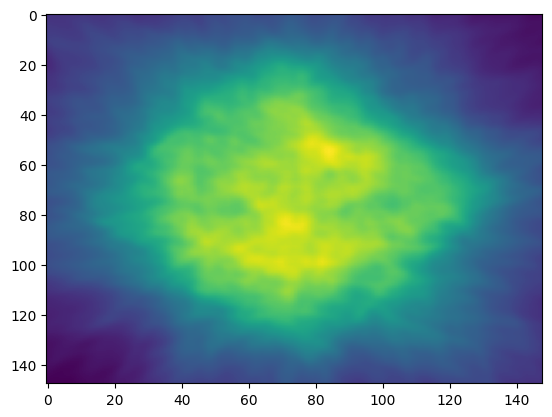

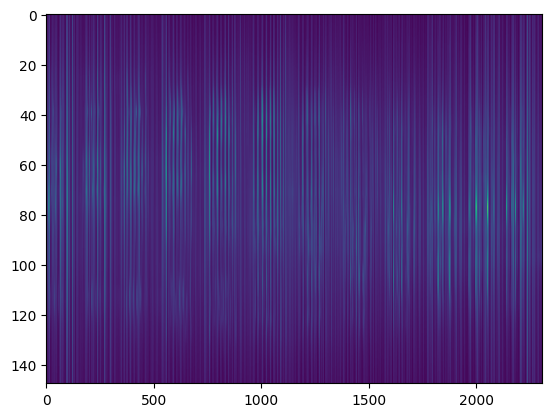

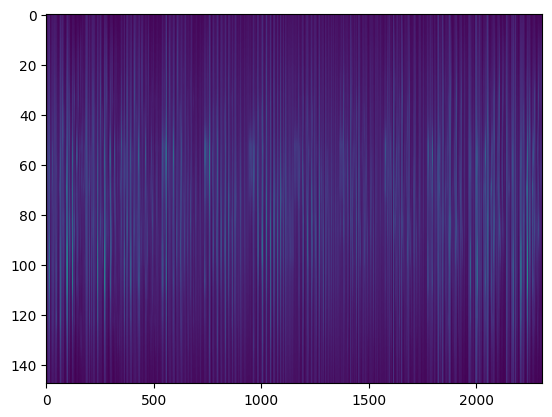

In [12]:
plt.imshow(adj_data_cpu.sum(axis=-1), aspect='auto')
plt.show()
plt.imshow(adj_data_cpu.sum(axis=0),aspect='auto')
plt.show()
plt.imshow(adj_data_cpu.sum(axis=1),aspect='auto')
plt.show()

In [13]:
print(K*Nx*Nx*4/1e9)
print(N_rot*Nx*N_seg*4/1e9)


0.202130112
1.5984


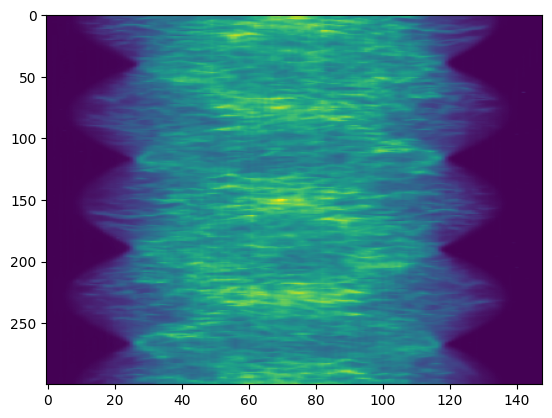

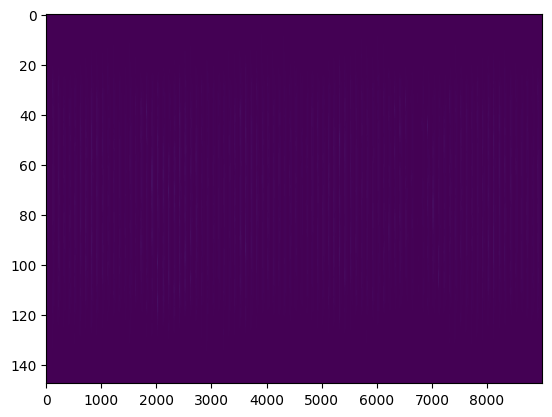

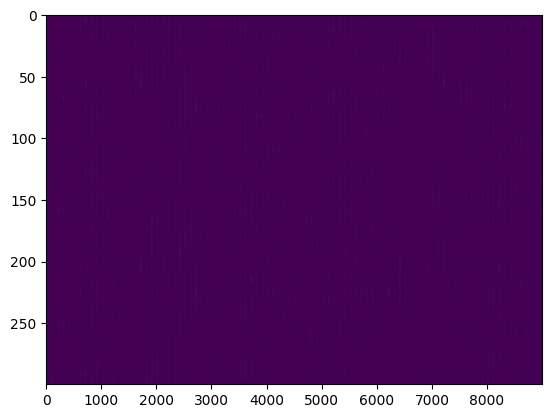

In [14]:
out = out_gpu.get()
plt.imshow(out.sum(axis=-1), aspect='auto')
plt.show()
plt.imshow(out.sum(axis=0),aspect='auto')
plt.show()
plt.imshow(out.sum(axis=1),aspect='auto')
plt.show()

In [15]:


queue = op.queue
Nx, Ny, K = op.Nx, op.Nx, op.K_sum  # or Ny separately if different

x0_gpu = clarray.zeros(
    queue,
    (Nx, Ny, K),
    dtype=np.float32,
    order="F",
)

out_cpu = np.ascontiguousarray(
    all_data_reshaped,
    dtype=np.float32
)
out_gpu = clarray.to_device(queue, out_cpu)
assert out_gpu.flags.c_contiguous


L = op.norm(max_iter=30)   # your power method result
print(L)
solver = FISTAOpenCL(op, prox_kind="nonneg_l1", lam=1e+5, L=L*50000)


x_sol_gpu = solver.run(x0_gpu, out_gpu, niter=100, verbose=1, diagnostics_interval=1)

7577130.0


/zhome/71/c/146676/texture_tomography/package/cil_addons/fista_opencl.py:163: RepeatedKernelRetrieval: Kernel 'copy_buf' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  self.fista_prg.copy_buf(q, (total_x,), None, x0_gpu.data, y.data, np.int32(total_x))


[iter    1/100] obj=1.445840e+13  f=1.445826e+13  g=1.393427e+08  ||x||=2.518049e-01  ||grad||=9.595234e+10  tau=2.640e-12  beta=0.000e+00


/zhome/71/c/146676/texture_tomography/package/cil_addons/fista_opencl.py:205: RepeatedKernelRetrieval: Kernel 'residual_axpb' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  self.fista_prg.residual_axpb(q, (total_Ax,), None, Ax.data, out_gpu.data, r.data, np.int32(total_Ax))
/zhome/71/c/146676/texture_tomography/package/cil_addons/fista_opencl.py:227: RepeatedKernelRetrieval: Kernel 'grad_step' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  self.fista_prg.grad_step(
/zhome/71/c/146676/texture_tomography/package/cil_addons/prox.py:54: RepeatedKernelRetrieval: Kernel 'prox_nonneg_l1' has been retrieved more than once. Each retrieva

[iter    2/100] obj=1.346150e+13  f=1.346142e+13  g=8.712254e+07  ||x||=2.565966e-01  ||grad||=5.891279e+10  tau=2.640e-12  beta=2.818e-01
[iter    3/100] obj=1.297751e+13  f=1.297739e+13  g=1.148857e+08  ||x||=3.620194e-01  ||grad||=3.829977e+10  tau=2.640e-12  beta=4.340e-01
[iter    4/100] obj=1.269510e+13  f=1.269498e+13  g=1.186226e+08  ||x||=4.327666e-01  ||grad||=4.373666e+10  tau=2.640e-12  beta=5.311e-01
[iter    5/100] obj=1.248845e+13  f=1.248833e+13  g=1.234569e+08  ||x||=5.048188e-01  ||grad||=3.850028e+10  tau=2.640e-12  beta=5.988e-01
[iter    6/100] obj=1.234612e+13  f=1.234599e+13  g=1.275352e+08  ||x||=5.750741e-01  ||grad||=4.100107e+10  tau=2.640e-12  beta=6.489e-01
[iter    7/100] obj=1.222868e+13  f=1.222855e+13  g=1.308001e+08  ||x||=6.430844e-01  ||grad||=4.282144e+10  tau=2.640e-12  beta=6.876e-01
[iter    8/100] obj=1.213004e+13  f=1.212991e+13  g=1.333761e+08  ||x||=7.088502e-01  ||grad||=4.428057e+10  tau=2.640e-12  beta=7.185e-01
[iter    9/100] obj=1.20455

In [16]:
op.print_gpu_memory_summary()


=== GPU MEMORY SUMMARY ===
GPU memory usage:
  _coeffs_gpu_full_sino         :   390.74 MB
  _coeffs_t_gpu[0]              :   390.74 MB
  _out_sub[0]                   :   564.01 MB
  _x_full_gpu                   :   390.74 MB
  full_idx_gpu[0]               :     0.01 MB
TOTAL: 1736.25 MB



In [17]:
print(300*148*9000*4/1e9)
print(148*148*340*4/1e9)
print(672*300*9000*4/1e9)

1.5984
0.02978944
7.2576


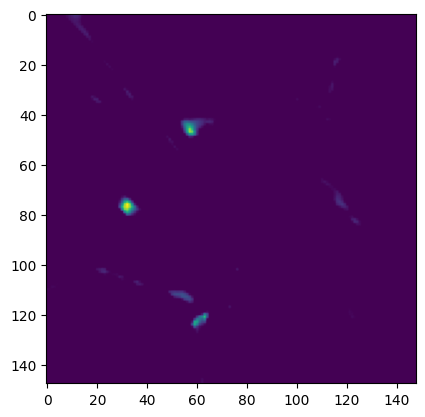

In [21]:
coeffs = x_sol_gpu.get()
plt.imshow(coeffs[:,:,40:50].sum(axis=-1))

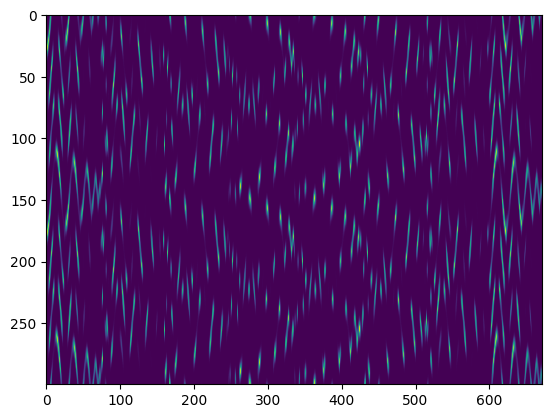

In [11]:
mat = forward.setup_matrix(i_mat = 0)
plt.imshow(mat.get()[:,:,10], aspect='auto')

In [12]:
print(forward.K_sum)
print(K_list)


672
[672]


In [13]:
initial = ag_M.allocate(0.01)
all_data_reshaped = all_data.reshape((N_rot, Nx, N_seg))
data = AcquisitionData(all_data_reshaped, geometry = ag_M)
#data_out = 1e-4*AcquisitionData(all_data.reshape((N_rot, Nx, N_seg)).astype(np.float32), geometry=ag_M)
out2 = forward.adjoint(data)

MemoryError: clEnqueueNDRangeKernel failed: MEM_OBJECT_ALLOCATION_FAILURE

In [ ]:
# initial = ig_K.allocate(0)
# F_fista = LeastSquares(forward, data)
# G_fista = IndicatorBox(lower=0.0)   # nonnegativity

# fista = FISTA(f=F_fista,
#               g=G_fista,
#               initial=initial,
#               update_objective_interval=1)


INFO:Numba backend is used.
INFO:Assuming that x is a numpy array or a number
INFO:FISTA setting up
INFO:FISTA configured


In [ ]:
# back1 = forward.adjoint(data)
# forward1 = forward.direct(back1)

<Figure size 640x480 with 0 Axes>

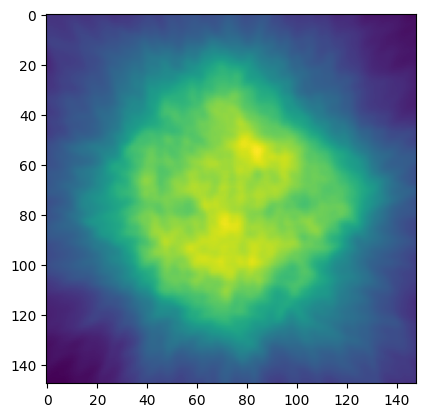

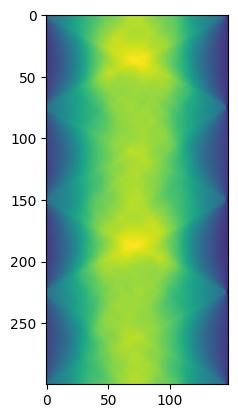

<Figure size 640x480 with 0 Axes>

In [ ]:
# plt.imshow(back1.as_array().sum(axis=-1))
# plt.figure()
# plt.imshow(forward1.as_array().sum(axis=-1))
# plt.figure()

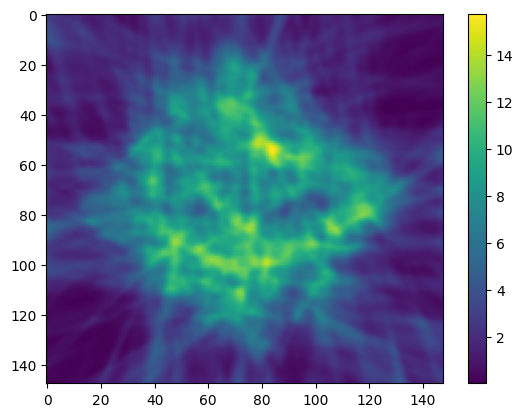

In [ ]:
plt.imshow((coeffs)[:,:,:].sum(axis=-1), aspect='auto')
plt.colorbar()
#plt.clim([1098,1110])
plt.show()

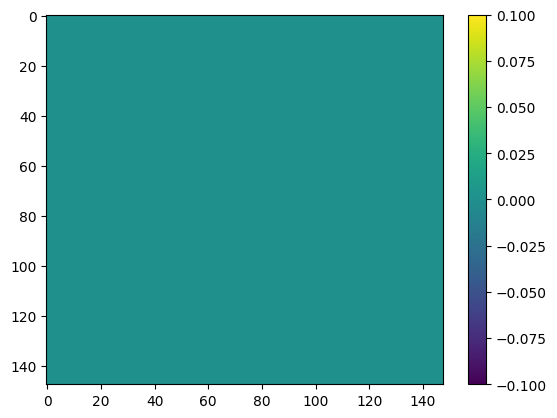

In [ ]:
plt.imshow((out2.as_array())[:,:,3000:4000].sum(axis=-1), aspect='auto')
plt.colorbar()
#plt.clim([1098,1110])
plt.show()